# Laboratorio 04 — IS-484: Preparación de Datos y Flujo de Trabajo de ML
## Trabajo en Clase — `estudiantes_sistemas.csv`

**Nombre y apellido:** Garcia Huaman, Roy Manuel

Sigue cada actividad de la Sección 4 de la guía, en orden. Ejecuta todas las
celdas y responde las preguntas marcadas **Responder** en una celda markdown
inmediatamente debajo.

## 4.1 Verificación del entorno de trabajo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


## 4.2 Importación e inspección inicial

**Parte A:** cargar el dataset y revisar dimensiones y tipos.

In [2]:
estudiantes = pd.read_csv("estudiantes_sistemas.csv")
print("Dimensiones:", estudiantes.shape)
estudiantes.dtypes

Dimensiones: (186, 9)


edad                       int64
turno                        str
tipo_colegio                 str
nivel_socioeconomico         str
tiene_laptop_propia          str
horas_estudio_semanal    float64
asistencia_pct           float64
promedio_previo          float64
aprobado                   int64
dtype: object

**Parte B:** estadísticos descriptivos y conteo de valores faltantes.

In [3]:
estudiantes.describe(include="all")

,edad,turno,tipo_colegio,nivel_socioeconomico,tiene_laptop_propia,horas_estudio_semanal,asistencia_pct,promedio_previo,aprobado
count,186.000000,186,175,179,186,170.000000,176.000000,181.000000,186.000000
unique,NaN,6,6,4,5,NaN,NaN,NaN,NaN
top,NaN,Mañana,Público,Medio,Sí,NaN,NaN,NaN,NaN
freq,NaN,83,99,92,110,NaN,NaN,NaN,NaN
mean,20.284946,NaN,NaN,NaN,NaN,10.560588,81.531250,14.896133,0.833333
std,4.018806,NaN,NaN,NaN,NaN,5.234482,11.174542,2.015092,0.373684
min,17.000000,NaN,NaN,NaN,NaN,0.000000,52.000000,9.500000,0.000000
25%,18.000000,NaN,NaN,NaN,NaN,7.700000,74.800000,13.700000,1.000000
50%,20.000000,NaN,NaN,NaN,NaN,10.250000,82.100000,14.800000,1.000000
75%,22.000000,NaN,NaN,NaN,NaN,13.175000,87.450000,16.200000,1.000000


In [4]:
estudiantes.isna().sum()

edad                      0
turno                     0
tipo_colegio             11
nivel_socioeconomico      7
tiene_laptop_propia       0
horas_estudio_semanal    16
asistencia_pct           10
promedio_previo           5
aprobado                  0
dtype: int64

**Responder:** ¿cuántas observaciones y cuántas variables tiene el dataset?
¿qué columnas tienen valores faltantes, y cuántos?

*Tu respuesta aquí:*

**Parte C:** distribución de variables categóricas y de `promedio_previo`.

turno
Mañana    83
Tarde     61
Noche     38
mañana     2
NOCHE      1
Manana     1
Name: count, dtype: int64

tipo_colegio
Público      99
Privado      71
NaN          11
Publico       2
privado       1
 Público      1
PRIVADO       1
Name: count, dtype: int64

nivel_socioeconomico
Medio    92
Bajo     48
Alto     38
NaN       7
bajo      1
Name: count, dtype: int64

tiene_laptop_propia
Sí      110
No       73
NO        1
 No       1
SÍ        1
Name: count, dtype: int64



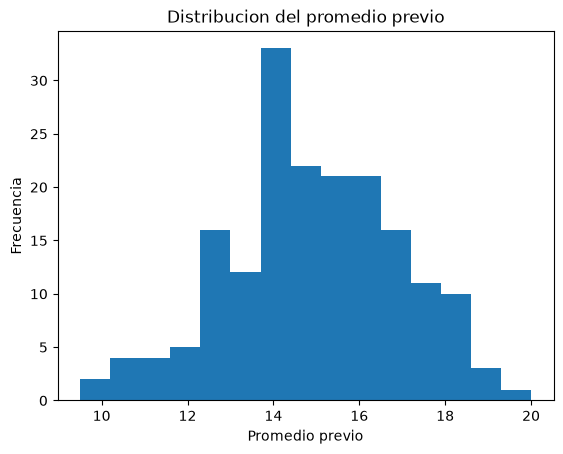

In [5]:
columnas_cat = ["turno", "tipo_colegio", "nivel_socioeconomico", "tiene_laptop_propia"]
for columna in columnas_cat:
    print(estudiantes[columna].value_counts(dropna=False))
    print()

plt.hist(estudiantes["promedio_previo"].dropna(), bins=15)
plt.xlabel("Promedio previo")
plt.ylabel("Frecuencia")
plt.title("Distribucion del promedio previo")
plt.show()

## 4.3 Limpieza de datos

**Parte A:** normalizar el texto de las columnas categóricas (quitar espacios,
pasar a minúsculas, eliminar tildes), para que una misma categoría quede escrita
siempre igual.

In [6]:
import unicodedata

def normalizar_texto(valor):
    if pd.isna(valor):
        return valor
    texto = valor.strip()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return texto.lower()

columnas_texto = [
    "turno", "tipo_colegio", "nivel_socioeconomico", "tiene_laptop_propia"
]
for columna in columnas_texto:
    estudiantes[columna] = estudiantes[columna].apply(normalizar_texto)
    valores = sorted(estudiantes[columna].dropna().unique().tolist())
    print(columna, "->", valores)

turno -> ['manana', 'noche', 'tarde']
tipo_colegio -> ['privado', 'publico']
nivel_socioeconomico -> ['alto', 'bajo', 'medio']
tiene_laptop_propia -> ['no', 'si']


**Parte B:** detectar y eliminar duplicados. El conteo de duplicados es mayor
que si se buscara *antes* de normalizar el texto (Parte A): algunas filas idénticas
estaban "disfrazadas" por una inconsistencia.

In [7]:
print("Duplicados exactos (tras normalizar texto):", estudiantes.duplicated().sum())
estudiantes = estudiantes.drop_duplicates().reset_index(drop=True)
print("Dimensiones tras eliminar duplicados:", estudiantes.shape)

Duplicados exactos (tras normalizar texto): 6
Dimensiones tras eliminar duplicados: (180, 9)


**Parte C:** tratar valores atípicos con dos métodos. `edad` y `asistencia_pct`
tienen un límite lógico claro; `horas_estudio_semanal` no, así que se usa el
rango intercuartílico (RIC).

In [8]:
print("Edad maxima antes:", estudiantes["edad"].max())
print("Asistencia maxima antes:", estudiantes["asistencia_pct"].max())

estudiantes.loc[estudiantes["edad"] > 40, "edad"] = np.nan
estudiantes.loc[estudiantes["asistencia_pct"] > 100, "asistencia_pct"] = np.nan

Edad maxima antes: 68
Asistencia maxima antes: 134.0


In [9]:
Q1 = estudiantes["horas_estudio_semanal"].quantile(0.25)
Q3 = estudiantes["horas_estudio_semanal"].quantile(0.75)
RIC = Q3 - Q1
limite_inferior = Q1 - 1.5 * RIC
limite_superior = Q3 + 1.5 * RIC

atipicos = estudiantes[
    (estudiantes["horas_estudio_semanal"] < limite_inferior)
    | (estudiantes["horas_estudio_semanal"] > limite_superior)
]
print("Atipicos detectados por RIC:", len(atipicos))
atipicos[["horas_estudio_semanal"]]

Atipicos detectados por RIC: 2


,horas_estudio_semanal
106,21.6
110,55.0


In [10]:
estudiantes.loc[atipicos.index, "horas_estudio_semanal"] = np.nan

**Parte D:** imputar valores faltantes (mediana en numéricas, moda en categóricas).

In [11]:
numericas = [
    "edad", "horas_estudio_semanal", "asistencia_pct", "promedio_previo"
]
for columna in numericas:
    estudiantes[columna] = estudiantes[columna].fillna(estudiantes[columna].median())

categoricas = ["tipo_colegio", "nivel_socioeconomico"]
for columna in categoricas:
    estudiantes[columna] = estudiantes[columna].fillna(estudiantes[columna].mode()[0])

estudiantes.isna().sum()

edad                     0
turno                    0
tipo_colegio             0
nivel_socioeconomico     0
tiene_laptop_propia      0
horas_estudio_semanal    0
asistencia_pct           0
promedio_previo          0
aprobado                 0
dtype: int64

## 4.4 Codificación de variables categóricas

**Parte A:** `nivel_socioeconomico` (ordinal), con los valores normalizados en la Actividad 4.3.

In [12]:
orden_nivel = {"bajo": 0, "medio": 1, "alto": 2}
estudiantes["nivel_socioeconomico_cod"] = (
    estudiantes["nivel_socioeconomico"].map(orden_nivel)
)
estudiantes[["nivel_socioeconomico", "nivel_socioeconomico_cod"]].head()

,nivel_socioeconomico,nivel_socioeconomico_cod
0,medio,1
1,medio,1
2,alto,2
3,alto,2
4,medio,1


**Parte B:** `tiene_laptop_propia` (binaria).

In [13]:
estudiantes["tiene_laptop_propia_cod"] = LabelEncoder().fit_transform(
    estudiantes["tiene_laptop_propia"]
)
estudiantes[["tiene_laptop_propia", "tiene_laptop_propia_cod"]].head()

,tiene_laptop_propia,tiene_laptop_propia_cod
0,no,0
1,no,0
2,si,1
3,si,1
4,si,1


**Parte C:** `turno` y `tipo_colegio` (nominales) con One-Hot Encoding.

In [14]:
estudiantes = pd.get_dummies(estudiantes, columns=["turno", "tipo_colegio"])
estudiantes.columns.tolist()

['edad',
 'nivel_socioeconomico',
 'tiene_laptop_propia',
 'horas_estudio_semanal',
 'asistencia_pct',
 'promedio_previo',
 'aprobado',
 'nivel_socioeconomico_cod',
 'tiene_laptop_propia_cod',
 'turno_manana',
 'turno_noche',
 'turno_tarde',
 'tipo_colegio_privado',
 'tipo_colegio_publico']

**Responder:** ¿cuántas columnas nuevas se crearon al codificar `turno`?
¿por qué esa cantidad coincide con el número de categorías de esa variable?

*Tu respuesta aquí:*

## 4.5 Normalización y estandarización

In [15]:
numericas = [
    "edad", "horas_estudio_semanal", "asistencia_pct", "promedio_previo"
]

minmax = MinMaxScaler()
ejemplo_minmax = minmax.fit_transform(estudiantes[numericas])
pd.DataFrame(ejemplo_minmax, columns=numericas).describe()

,edad,horas_estudio_semanal,asistencia_pct,promedio_previo
count,180.000000,180.000000,180.000000,180.000000
mean,0.500000,0.520615,0.609896,0.518307
std,0.322929,0.187804,0.213340,0.188190
min,0.000000,0.000000,0.000000,0.000000
25%,0.166667,0.390863,0.480729,0.407143
50%,0.500000,0.517766,0.627083,0.504762
75%,0.833333,0.649746,0.735417,0.640476
max,1.000000,1.000000,1.000000,1.000000


In [16]:
zscore = StandardScaler()
ejemplo_zscore = zscore.fit_transform(estudiantes[numericas])
pd.DataFrame(ejemplo_zscore, columns=numericas).describe()

,edad,horas_estudio_semanal,asistencia_pct,promedio_previo
count,1.800000e+02,1.800000e+02,1.800000e+02,1.800000e+02
mean,1.973730e-17,2.121760e-16,-5.828671e-16,-8.092292e-16
std,1.002789e+00,1.002789e+00,1.002789e+00,1.002789e+00
min,-1.552648e+00,-2.779851e+00,-2.866777e+00,-2.761844e+00
25%,-1.035098e+00,-6.928169e-01,-6.071397e-01,-5.923472e-01
50%,0.000000e+00,-1.520854e-02,8.078876e-02,-7.217558e-02
75%,1.035098e+00,6.895041e-01,5.900027e-01,6.509899e-01
max,1.552648e+00,2.559703e+00,1.833660e+00,2.566744e+00


**Responder:** ¿en qué rango quedan los valores después de Min-Max? ¿y después
de Z-score? ¿cuál de las dos técnicas produce valores negativos?

*Tu respuesta aquí:*

## 4.6 Separación de X e y, y división en entrenamiento y prueba

**Parte A:** definir `X` e `y`.

In [17]:
y = estudiantes["aprobado"]
X = estudiantes.drop(
    columns=["aprobado", "nivel_socioeconomico", "tiene_laptop_propia"]
)
X.shape, y.shape

((180, 11), (180,))

**Parte B:** dividir en entrenamiento (80%) y prueba (20%).

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((144, 11), (36, 11))

**Parte C:** escalar ajustando el escalador solo con el conjunto de entrenamiento.

In [19]:
columnas_numericas = [
    "edad", "horas_estudio_semanal", "asistencia_pct", "promedio_previo"
]

escalador = StandardScaler()
X_train[columnas_numericas] = escalador.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = escalador.transform(X_test[columnas_numericas])

X_train[columnas_numericas].describe()

,edad,horas_estudio_semanal,asistencia_pct,promedio_previo
count,1.440000e+02,1.440000e+02,1.440000e+02,1.440000e+02
mean,-3.854941e-16,2.312965e-17,8.018277e-16,1.480297e-15
std,1.003490e+00,1.003490e+00,1.003490e+00,1.003490e+00
min,-1.572929e+00,-2.793171e+00,-2.948986e+00,-2.767529e+00
25%,-1.063936e+00,-6.618861e-01,-5.741165e-01,-5.953221e-01
50%,-4.595074e-02,2.855419e-03,9.610762e-02,-9.015780e-02
75%,9.720349e-01,6.675969e-01,5.665291e-01,6.802178e-01
max,1.481028e+00,2.606997e+00,1.906977e+00,2.536697e+00
